# Weekly Average Histograms
This notebook generates a 2x2 grid of histograms for each product, where the Y-axis represents the week of the year and the X-axis represents the binned data of the weekly average.

In [26]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter
import warnings
from tqdm.auto import tqdm

# Settings
plt.style.use('default')
target_year = 2018

In [27]:
# Load the data
try:
    with open(r'E:\satdata\Custom\yucatan_sst_chlor_cdomslope_ssl_bathy_2010-2019_v3.pkl', 'rb') as f:
        data = pickle.load(f)

    df = data['data']
    metadata = data['metadata']
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Data file not found. Please check path.")

Data loaded successfully.


In [28]:
# r'$S_{275-295}$ $\text{ (nm}^{-1}\text{)}$'
# r'$S_{300-600}$ $\text{ (nm}^{-1}\text{)}$'
# r'$a_{\text{CDOM}}$ 412 $\text{ (m}^{-1}\text{)}$'
# r'$\log_{10}(\text{mg/m}^3)$'

In [29]:
# Filtering and grouping by week
# Instead of filtering for a single year, we use the entire dataset
df_all_years = df.copy()

# List of products (from raw_data.ipynb)
products = [
    'sst', 
    'chlorophyll', 
    'cdom_412', 
    'cdom_slope_275_295', 
    'cdom_slope_300_600', 
    'ssl'
]

product_info = {
    'sst': {'title': 'Sea Surface Temperature', 'unit': '°C', 'log': False},
    'chlorophyll': {'title': 'Chlorophyll-a', 'unit': r'$\log_{10}(\text{mg/m}^3)$', 'log': True},
    'cdom_412': {'title': 'CDOM 412', 'unit': r'$a_{\text{CDOM}}$ 412 $\text{ (m}^{-1}\text{)}$', 'log': False},
    'cdom_slope_275_295': {'title': 'CDOM Slope (275-295)', 'unit': r'$S_{275-295}$ $\text{ (nm}^{-1}\text{)}$', 'log': False},
    'cdom_slope_300_600': {'title': 'CDOM Slope (300-600)', 'unit': r'$S_{300-600}$ $\text{ (nm}^{-1}\text{)}$', 'log': False},
    'ssl': {'title': 'Sea Surface Level', 'unit': r'$\text{m}$', 'log': False}
}

In [30]:
available_products = [p for p in products if p in df_all_years.columns]
print(f"Available products: {available_products}")

# Pre-calculate weekly averages across all years
weekly_data = {p: [] for p in available_products}

# Group by week (ignoring year)
df_all_years['week'] = df_all_years.index.isocalendar().week

for week_num, week_df in tqdm(df_all_years.groupby('week'), desc="Processing weeks"):
    for p in available_products:
        grids = []
        for _, row in week_df.iterrows():
            grid = row.get(p)
            if grid is not None and not (isinstance(grid, float) and np.isnan(grid)):
                grid_arr = np.array(grid, dtype=float)
                if not np.isnan(grid_arr).all():
                    grids.append(grid_arr)
        
        if grids:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', category=RuntimeWarning)
                # Compute the average grid for this week across all years
                avg_grid = np.nanmean(np.stack(grids), axis=0)
                
                # Flatten and filter NaNs
                values = avg_grid.flatten()
                values = values[~np.isnan(values)]
                
                if product_info[p]['log']:
                    values = values[values > 0]
                    values = np.log10(values)
                
                if len(values) > 0:
                    # Store as (week, value) pairs
                    for val in values:
                        weekly_data[p].append({'week': week_num, 'value': val})

# Convert to DataFrames for easier plotting
for p in available_products:
    weekly_data[p] = pd.DataFrame(weekly_data[p])

Available products: ['sst', 'chlorophyll', 'cdom_412', 'cdom_slope_275_295', 'cdom_slope_300_600', 'ssl']


Processing weeks:   0%|          | 0/53 [00:00<?, ?it/s]

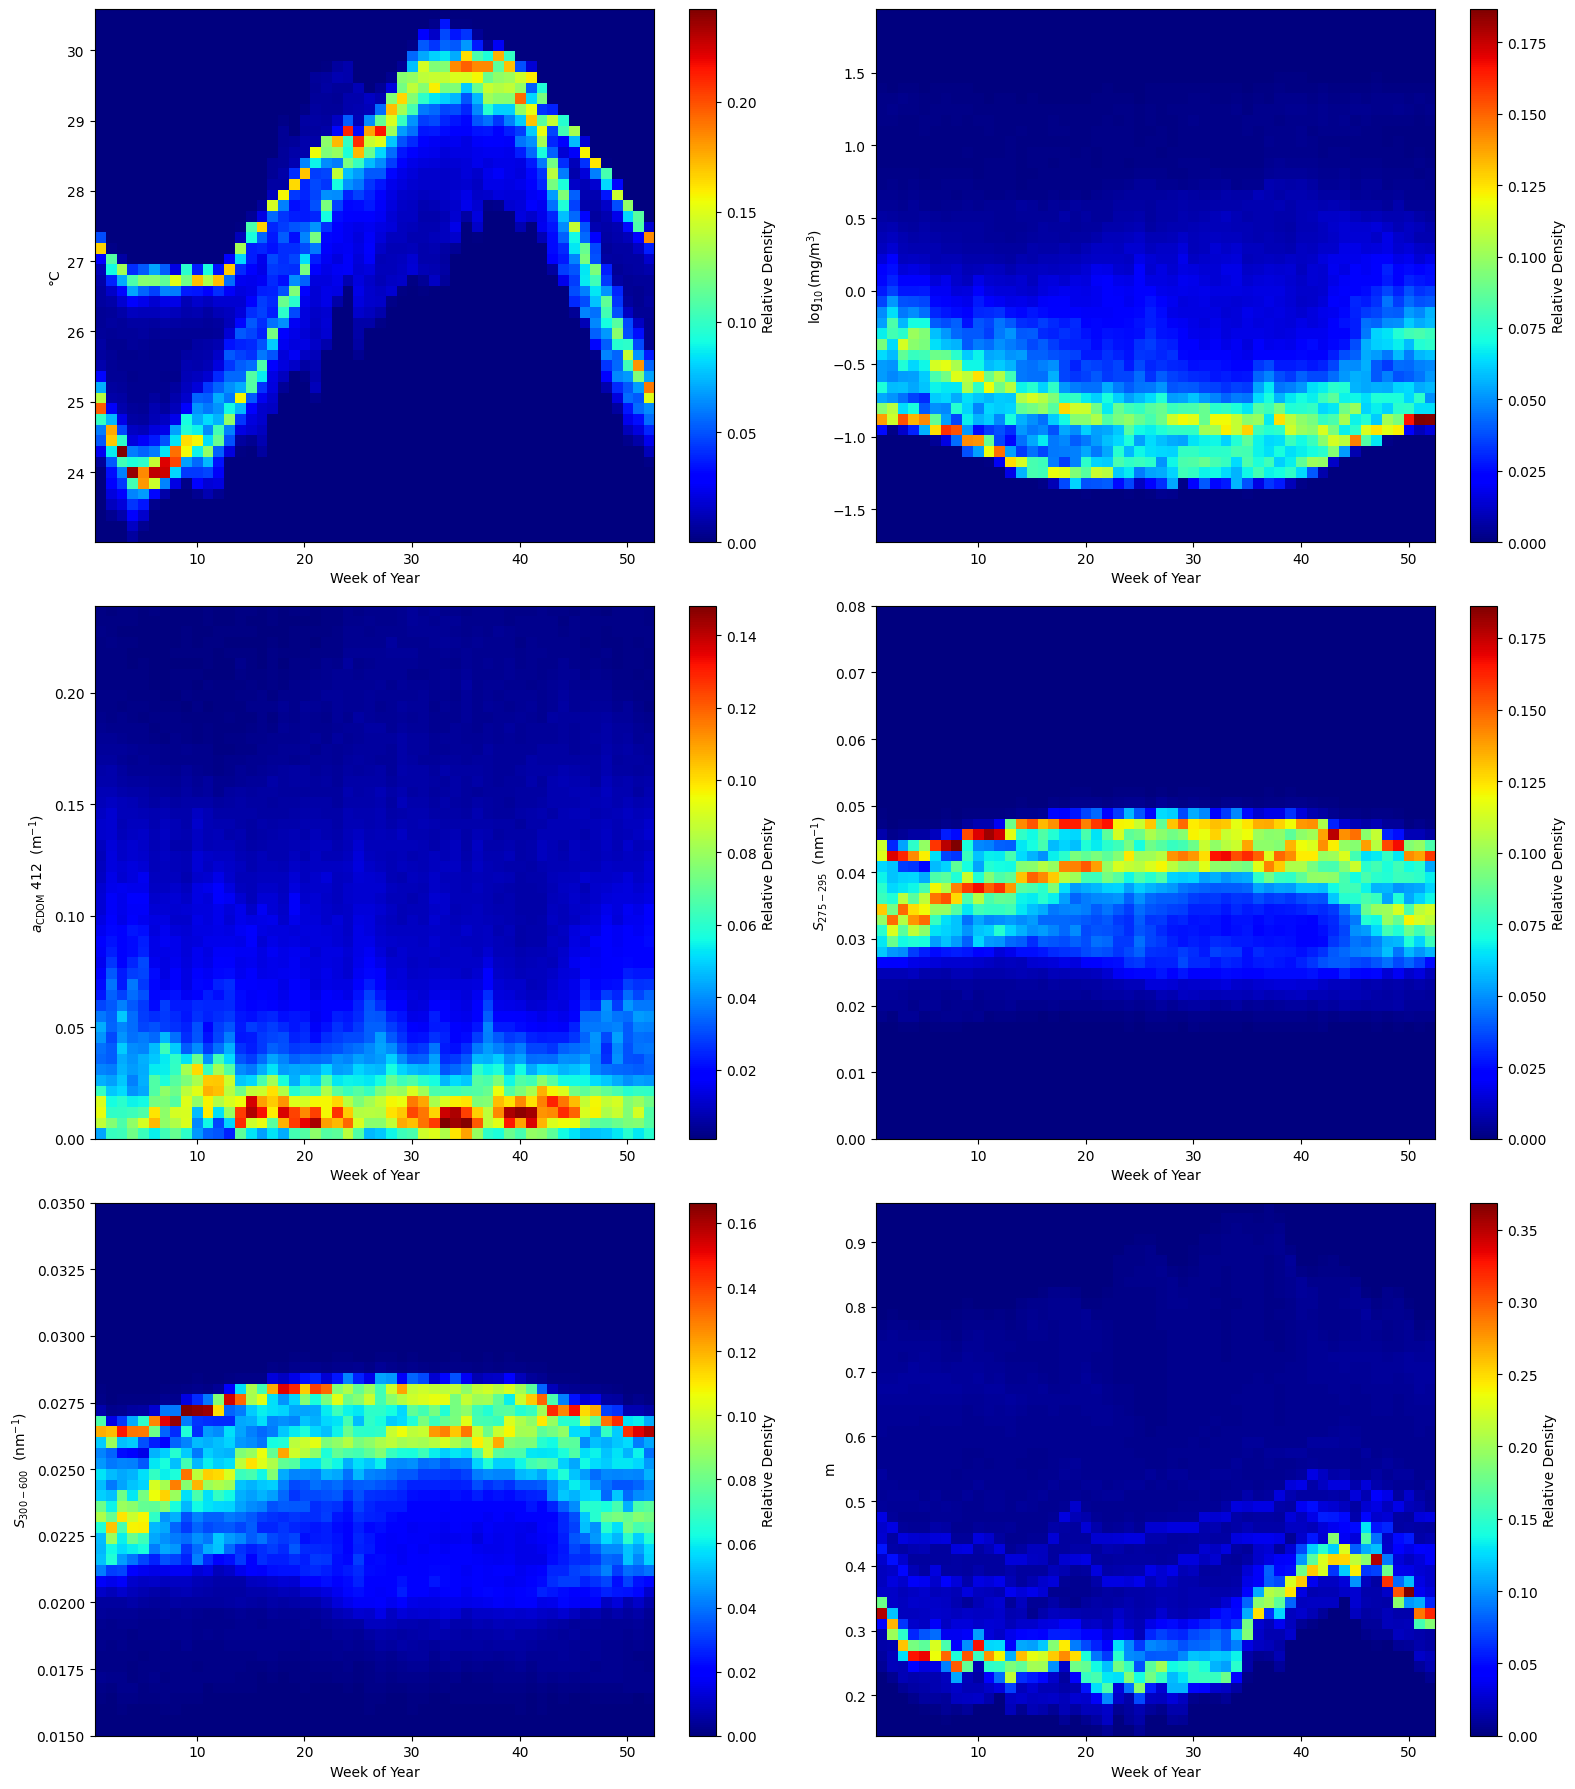

In [31]:
def plot_weekly_histograms(available_products, weekly_data, product_info):
    num_products = len(available_products)
    rows = (num_products + 1) // 2
    
    fig, axes = plt.subplots(rows, 2, figsize=(16, 6 * rows))
    axes = axes.flatten()

    for i, p in enumerate(available_products):
        ax = axes[i]
        df_p = weekly_data[p]
        
        if df_p.empty:
            ax.set_title(f"{product_info[p]['title']} - No Data")
            continue

        # Calculate bins (swap x/y for axes)
        y_bins = 50  # Now Y is the variable
        x_bins = np.arange(1, 54) - 0.5  # Now X is week

        # Determine y-range for bins
        if p == 'cdom_slope_275_295':
            range_y = [0, 0.08]
        elif p == 'cdom_slope_300_600':
            range_y = [0.015, 0.035]
        elif p == 'cdom_412':
            cdom_upper = np.nanpercentile(df_p['value'], 98)
            if not np.isfinite(cdom_upper) or cdom_upper <= 0:
                cdom_upper = 0.1
            range_y = [0, cdom_upper]
        else:
            range_y = [df_p['value'].min(), df_p['value'].max()]

        # Create 2D histogram (swap order)
        h, xedges, yedges = np.histogram2d(
            df_p['week'], df_p['value'],
            bins=[x_bins, y_bins],
            range=[[0.5, 52.5], range_y]
        )

        # Normalize each week (now along axis 0)
        h_norm = h.copy()
        for j in range(h.shape[0]):
            row_sum = h[j, :].sum()
            if row_sum > 0:
                h_norm[j, :] = h[j, :] / row_sum

        # Plot as heatmap (transpose for correct orientation)
        im = ax.imshow(
            h_norm.T,
            origin='lower', aspect='auto',
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
            cmap='jet'
        )

        # ax.set_title(f"{product_info[p]['title']} (2018)", fontweight='bold')
        ax.set_xlabel('Week of Year')
        ax.set_ylabel(f"{product_info[p]['unit']}")
        plt.colorbar(im, ax=ax, label='Relative Density')

    # Remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_weekly_histograms(available_products, weekly_data, product_info)


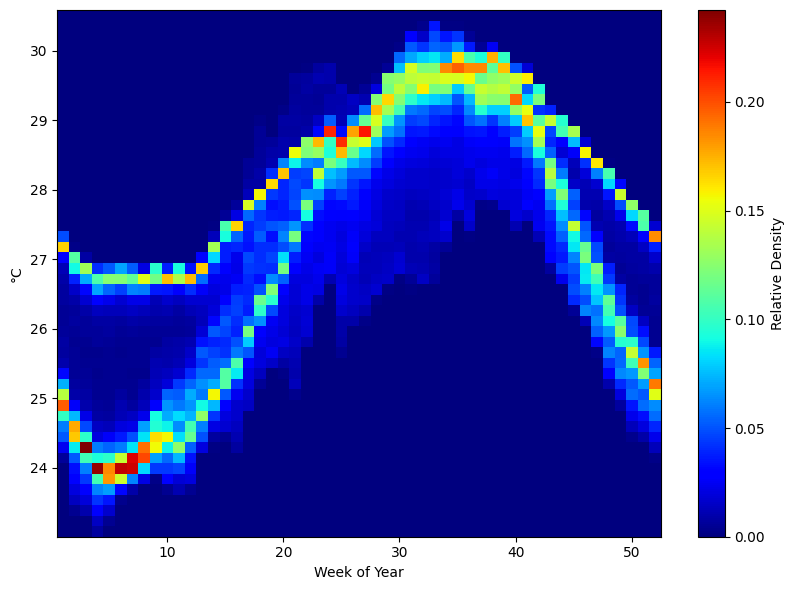

In [32]:
# Sea Surface Temperature
if 'sst' in weekly_data:
    plot_weekly_histograms(['sst'], weekly_data, product_info)

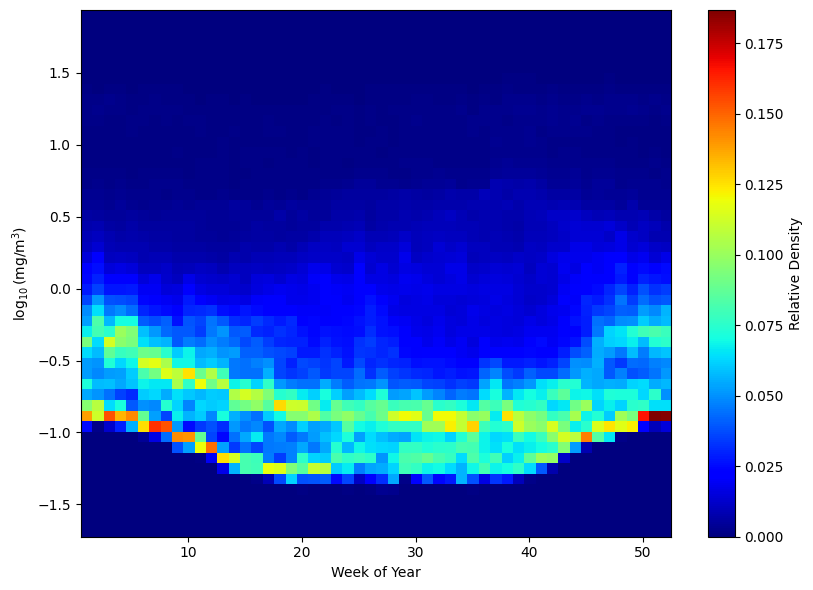

In [33]:
# Chlorophyll-a
if 'chlorophyll' in weekly_data:
    plot_weekly_histograms(['chlorophyll'], weekly_data, product_info)

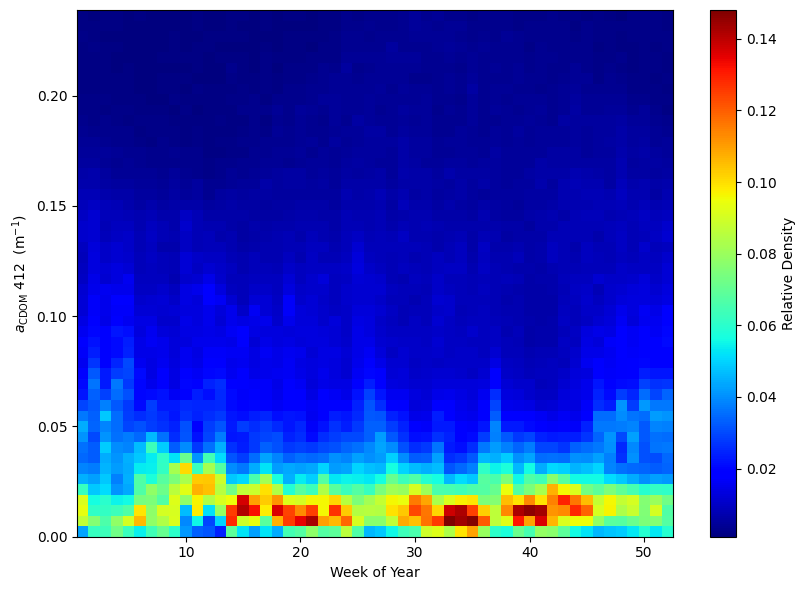

In [34]:
# CDOM 412
if 'cdom_412' in weekly_data:
    plot_weekly_histograms(['cdom_412'], weekly_data, product_info)

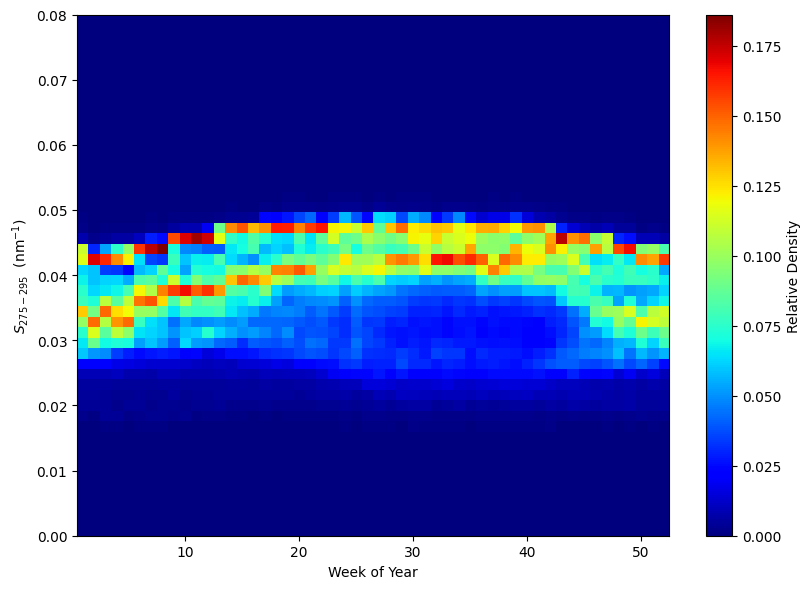

In [35]:
# CDOM Slope (275-295)
if 'cdom_slope_275_295' in weekly_data:
    plot_weekly_histograms(['cdom_slope_275_295'], weekly_data, product_info)

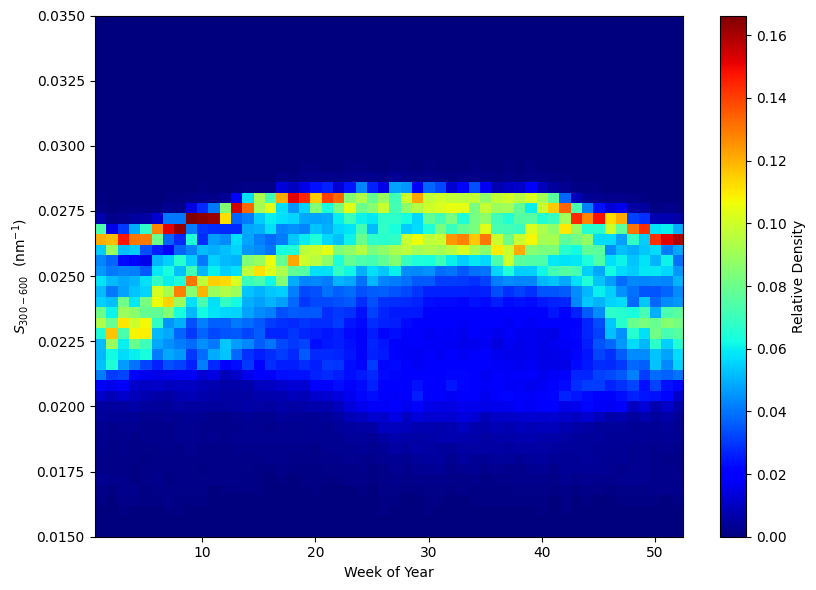

In [36]:
# CDOM Slope (300-600)
if 'cdom_slope_300_600' in weekly_data:
    plot_weekly_histograms(['cdom_slope_300_600'], weekly_data, product_info)

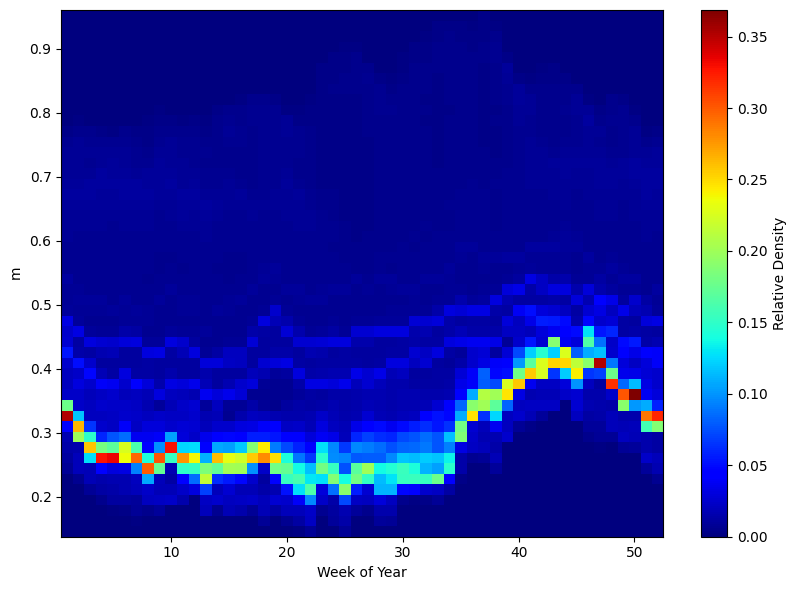

In [ ]:
# Sea Surface Level
if 'ssl' in weekly_data:
    plot_weekly_histograms(['ssl'], weekly_data, product_info)